# Assignment 1 - 46770 Integrated Energy Grids  
February 2026

In this first part of the course project, you are asked to carry out the tasks described below.

Write a short report (maximum length 6 pages) in groups of 4 students, including your main findings, and upload it to DTULearn.

Deadline for submission: March 25, 2026, 23:55


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pypsa

## Adding the data and cleaning
**Getting the Data Paths**

In [2]:
BASE_DIR = Path.cwd()  
DATA_DIR = BASE_DIR.parent / "data"
PLOTS_DIR = BASE_DIR.parent / "Plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENERATION_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv"
LOAD_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv"

**Read files + fixing column names**

In [3]:
print("Reading files...")
print("Generation file:", GENERATION_FILE)
print("Load file:", LOAD_FILE)

# Extracting the raw column names to understand the structure of the data
gen_raw = pd.read_csv(GENERATION_FILE)
load_raw = pd.read_csv(LOAD_FILE)

# Getting the column names and stripping (taking out) any leading/trailing whitespaces
gen_raw.columns = [str(c).strip() for c in gen_raw.columns]
load_raw.columns = [str(c).strip() for c in load_raw.columns]

print("\nGeneration columns:")
print(gen_raw.columns.tolist())

print("\nLoad columns:")
print(load_raw.columns.tolist())

# _____________________________________________________________________
# Fixing column names
GENERATION_TIME_COL = gen_raw.columns[0]
LOAD_TIME_COL = load_raw.columns[0]

# generation file expected columns
WIND_OFFSHORE_COL = "Wind offshore"
WIND_ONSHORE_COL = "Wind onshore"
SOLAR_COL = "Solar"  # IMPORTANT!: The historical solar generation data used in the model is aggregated and does not distinguish between rooftop and utility-scale PV.

# load file expected column
LOAD_COL = "Load"

Reading files...
Generation file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv
Load file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv

Generation columns:
['Date (GMT+1)', 'Wind offshore', 'Wind onshore', 'Solar']

Load columns:
['Date (GMT+1)', 'Load']


**Parsing dates**

In [4]:
def parse_time(series):
    # Turn data col into date time format
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except Exception:
        return pd.to_datetime(series, errors="coerce", utc=True)

gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
load_raw[LOAD_TIME_COL] = parse_time(load_raw[LOAD_TIME_COL])

gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
load_raw = load_raw.dropna(subset=[LOAD_TIME_COL]).copy()

gen_raw = gen_raw.set_index(GENERATION_TIME_COL)
load_raw = load_raw.set_index(LOAD_TIME_COL)

# If the time index of both load and generation files has timezone information:
# - First convert it to the "Europe/Berlin" timezone, which corresponds to the local
#   German electricity system time used in the datasets.
# - Then remove the timezone information (tz_localize(None)) to obtain a naive
#   datetime index.
#
# This ensures that:
# - The timestamps remain aligned with the German calendar year.
# - We avoid shifts caused by converting to UTC (which could move the first hour
#   of the year to the previous day).
# - The time index is easier to work with in PyPSA and pandas operations.
if getattr(gen_raw.index, "tz", None) is not None:
    gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    gen_raw.index.name = "Date"

if getattr(load_raw.index, "tz", None) is not None:
    load_raw.index = load_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    load_raw.index.name = "Date"

**Data cleaning**

In [5]:
def parse_number(series):
    # Turn data col into numeric format, removing any non-numeric characters (like spaces, commas, etc.)
    s = series.astype(str).str.strip()
    s = s.str.replace("\u202f", "", regex=False)
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

gen = pd.DataFrame(index=gen_raw.index)
gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
gen["solar"] = parse_number(gen_raw[SOLAR_COL])

load = pd.DataFrame(index=load_raw.index)
load["load"] = parse_number(load_raw[LOAD_COL])

# Join generation and load dataframes on their time index, keeping only the rows where both have data (inner join)
df = gen.join(load, how="inner")
df = df.dropna().copy()
df = df.groupby(df.index).mean()
df = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")].copy()

# Convert 15-minute data to hourly averages
df = df.resample("1h").mean()
df = df.interpolate(method="time")  

# Remove Feb 29 so the year has 8760 hours
df = df[~((df.index.month == 2) & (df.index.day == 29))].copy()

print("\nFirst rows:")
print(df.head())

print("\nShape:")
print(df.shape)


First rows:
                     wind_offshore  wind_onshore  solar       load
Date                                                              
2024-01-01 00:00:00       5682.425     29106.525    0.0  42896.250
2024-01-01 01:00:00       5348.775     29017.375    0.0  41452.550
2024-01-01 02:00:00       5191.500     29096.325    0.0  40416.100
2024-01-01 03:00:00       4676.750     28569.225    0.0  39642.625
2024-01-01 04:00:00       4441.875     28502.700    2.0  39247.775

Shape:
(8760, 4)


# Section A
Choose one country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the costs and other technological assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.


### Technology 
#### Capacity factors

Data taken from: 
https://energy-charts.info/charts/installed_power/chart.htm?l=en&c=DE&year=2024


In [6]:
WIND_ONSHORE_CAPACITY_MW    = 63590
WIND_OFFSHORE_CAPACITY_MW   = 9220
SOLAR_CAPACITY_MW           = 92410
GAS_INSTALLED_CAPACITY_MW   = 35600

wind_onshore_cf     = (df["wind_onshore"] / WIND_ONSHORE_CAPACITY_MW).clip(lower=0, upper=1)
wind_offshore_cf    = (df["wind_offshore"] / WIND_OFFSHORE_CAPACITY_MW).clip(lower=0, upper=1)
solar_cf            = (df["solar"] / SOLAR_CAPACITY_MW).clip(lower=0, upper=1)
demand_series       = df["load"].clip(lower=0)

print("Onshore wind mean capacity factor:", wind_onshore_cf.mean())
print("Offshore wind mean capacity factor:", wind_offshore_cf.mean())
print("Utility solar mean capacity factor:", solar_cf.mean())
#.clip(lower, uppper) are basically used to ensure that any data point is not negative or goes beyond 1, 
# which is important for capacity factors and demand.

Onshore wind mean capacity factor: 0.19794465795072744
Offshore wind mean capacity factor: 0.3162542003437039
Utility solar mean capacity factor: 0.09163482743792677


#### Cost assumptions
SOURCE: https://www.sciencedirect.com/science/article/pii/S0196890419309835 


Found the co2 price here, I saw for CCGT it ranges fro 90$/tCO2 to 103$/tCO2, I took a value in the middle and turned it into euros 96.5$ = 84.15 €
https://publications.ieaghg.org/technicalreports/2024-03%20Techno-Economic%20Assessment%20of%20Small-Scale%20Carbon%20Capture%20for%20Industrial%20and%20Power%20Systems.pdf

In [7]:
def annuity(n, r):
    # Annuity is basically a way to calculate the equivalent annual cost of an investment, taking into account the time value of money.
    """Annuity factor for lifetime n years and discount rate r."""
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    else:
        return 1.0 / n

In [8]:
discount_rate = 0.07

# Onshore wind
lifetime_ONW = 30  # years
ONW_CAPEX_MW = 910000 # EUR/MW
fixed_OM_onshorewind = 0.033
capital_cost_onshorewind = annuity(lifetime_ONW, discount_rate) * ONW_CAPEX_MW * (1 + fixed_OM_onshorewind)   # EUR/MW-year
marginal_cost_onshorewind = 0

# Offshore wind
lifetime_OFW = 25  # years
OFW_CAPEX_MW = 2506000 # EUR/MW
fixed_OM_offshorewind = 0.03
capital_cost_offshorewind = annuity(lifetime_OFW, discount_rate) * OFW_CAPEX_MW * (1 + fixed_OM_offshorewind)   # EUR/MW-year
marginal_cost_offshorewind = 0

# Solar PV - UTILITY SCALE
lifetime_PV = 25  # years
PV_CAPEX_MW = 425000 # EUR/MW - Utility scale figures
fixed_OM_solar = 0.03
capital_cost_solar = annuity(lifetime_PV, discount_rate) * PV_CAPEX_MW * (1 + fixed_OM_solar)           # EUR/MW-year
marginal_cost_solar = 0

# Gas (as OCGT, Open Cycle Gas Turbine)
# In our data source for the amount of gas installed in DEU it is not specified if its CCGT or OCGT
# but since the paper found has OCGT numbers, we will assume it is OCGT, which has a shorter lifetime and higher fuel costs than CCGT.
lifetime_GAS = 25  # years
GAS_CAPEX_MW = 560000 # EUR/MW
fixed_OM_gas = 0.033
capital_cost_gas = annuity(lifetime_GAS, discount_rate) * GAS_CAPEX_MW * (1 + fixed_OM_gas) # EUR/MW-year
fuel_cost_gas = 21.6                                      # EUR/MWh_th
efficiency_gas = 0.39
emission_factor_gas = 0.19                                # tCO2/MWh_th
co2_intensity_gas = emission_factor_gas / efficiency_gas  # tCO2/MWh_el
co2_price = 84.15                                         # €/tCO2 
marginal_cost_gas = fuel_cost_gas / efficiency_gas + co2_price * co2_intensity_gas   # EUR/MWh_el

### Network build

In [9]:
n = pypsa.Network()
n.set_snapshots(df.index)

# ___ CARRIERS ___
n.add("Carrier", "electricity")
n.add("Carrier", "wind_onshore")
n.add("Carrier", "wind_offshore")
n.add("Carrier", "solar")
n.add("Carrier", "gas")

# ___ BUSES ___
n.add("Bus", "electricity", carrier="electricity")

# ___ LOADS ___
n.add("Load", "demand", bus="electricity", p_set=demand_series)

# ___ GENERATORS ___
n.add(
    "Generator",
    "wind_onshore",
    bus="electricity",
    carrier="wind_onshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_onshorewind,
    marginal_cost=marginal_cost_onshorewind,
    p_max_pu=wind_onshore_cf
)

n.add(
    "Generator",
    "wind_offshore",
    bus="electricity",
    carrier="wind_offshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_offshorewind,
    marginal_cost=marginal_cost_offshorewind,
    p_max_pu=wind_offshore_cf
)

n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_nom_extendable=True,
    capital_cost=capital_cost_solar,
    marginal_cost=marginal_cost_solar,
    p_max_pu=solar_cf
)

n.add(
    "Generator",
    "gas",
    bus="electricity",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=capital_cost_gas,
    marginal_cost=marginal_cost_gas,
    p_max_pu=1.0    # Alwayas available
)


n.buses.index       = n.buses.index.astype(object)
n.loads.index       = n.loads.index.astype(object)
n.generators.index  = n.generators.index.astype(object)
n.loads["bus"]      = n.loads["bus"].astype(object)
n.generators["bus"] = n.generators["bus"].astype(object)

**Optimize**

In [10]:
print("\nRunning Optimization...")
n.optimize(solver_name="highs")


Running Optimization...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 168.77it/s]
INFO:linopy.io: Writing time: 0.24s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.61e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [11]:
print("\nOptimal capacities (MW):")
print(n.generators.p_nom_opt)


Optimal capacities (MW):
name
wind_onshore     172012.565506
wind_offshore        -0.000000
solar            122564.021221
gas               71202.428511
Name: p_nom_opt, dtype: float64


### Plots

#### Summer Dispatch

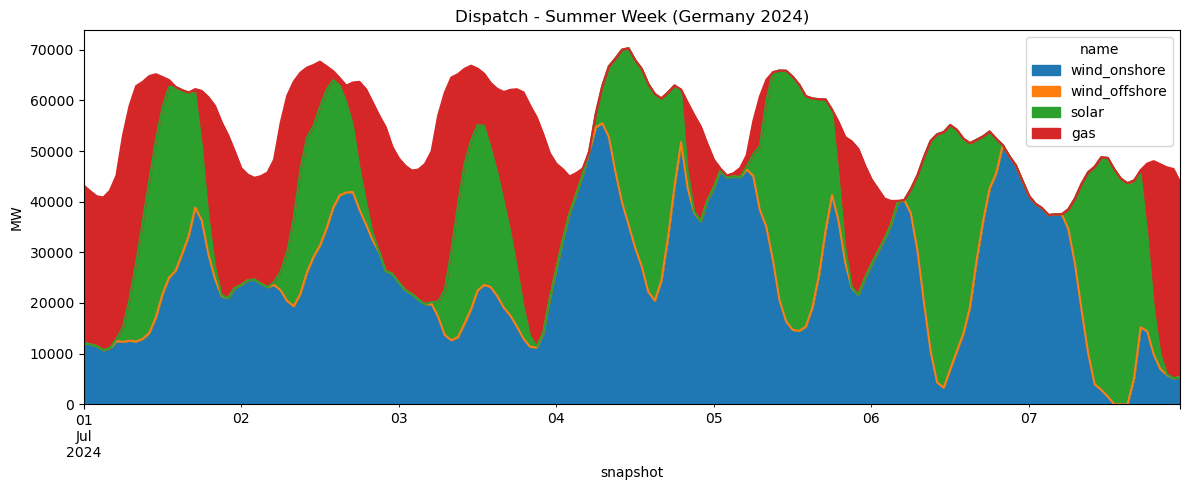


Saved figure in Plots folder.


In [12]:
summer = n.generators_t.p.loc["2024-07-01":"2024-07-07"]
summer.plot.area(figsize=(12, 5))
plt.title("Dispatch - Summer Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "summer_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Winter Dispatch

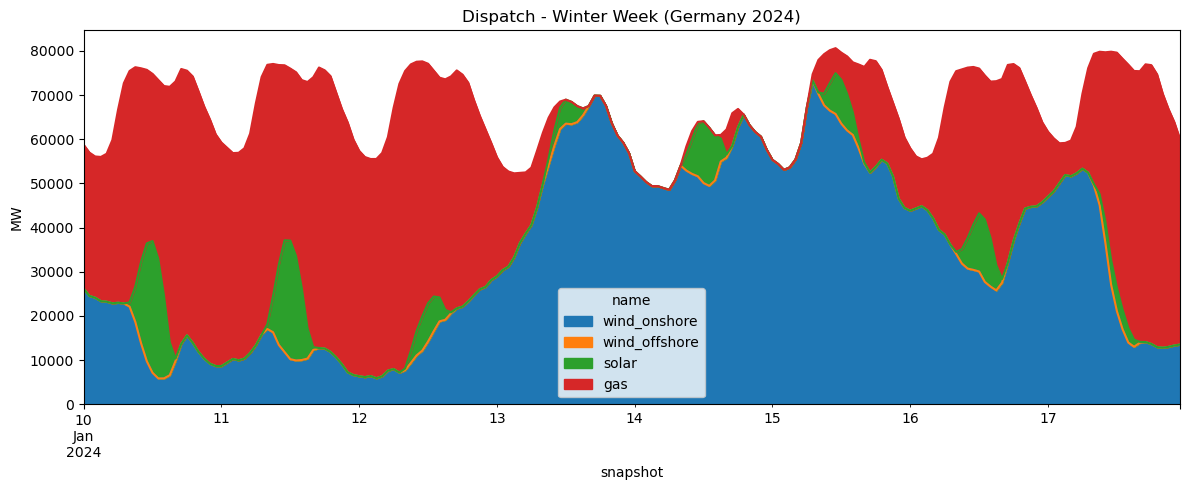


Saved figure in Plots folder.


In [13]:
winter = n.generators_t.p.loc["2024-01-10":"2024-01-17"]
winter.plot.area(figsize=(12, 5))
plt.title("Dispatch - Winter Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "winter_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Annual Mix

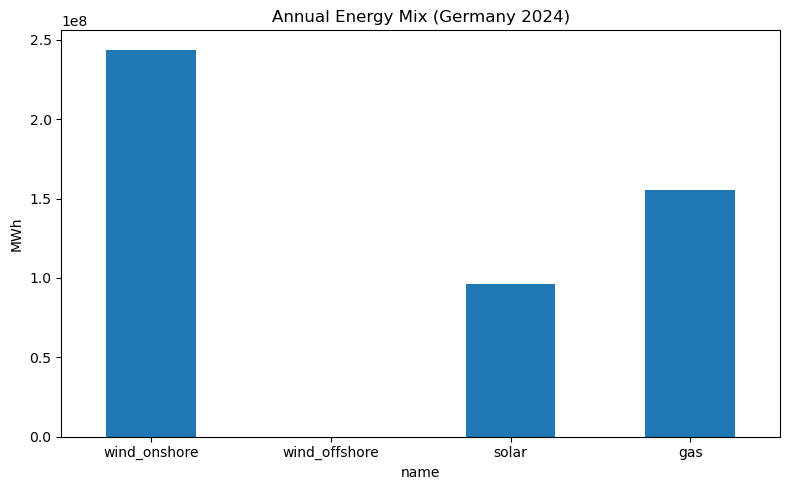


Saved figure in Plots folder.

Annual energy production (MWh):
name
wind_onshore     2.438686e+08
wind_offshore    0.000000e+00
solar            9.633339e+07
gas              1.553396e+08
dtype: float64

Capacity factors:
name
wind_onshore     0.161842
wind_offshore         NaN
solar            0.089724
gas              0.249048
dtype: float64


In [28]:
annual_mix = n.generators_t.p.sum()
annual_mix.plot(kind="bar", figsize=(8, 5))
plt.title("Annual Energy Mix (Germany 2024)")
plt.ylabel("MWh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "annual_mix.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

print("\nAnnual energy production (MWh):")
print(annual_mix)

capacity_factor = n.generators_t.p.sum() / (n.generators.p_nom_opt * len(n.snapshots))

print("\nCapacity factors:")
print(capacity_factor)

#### Duration Curves

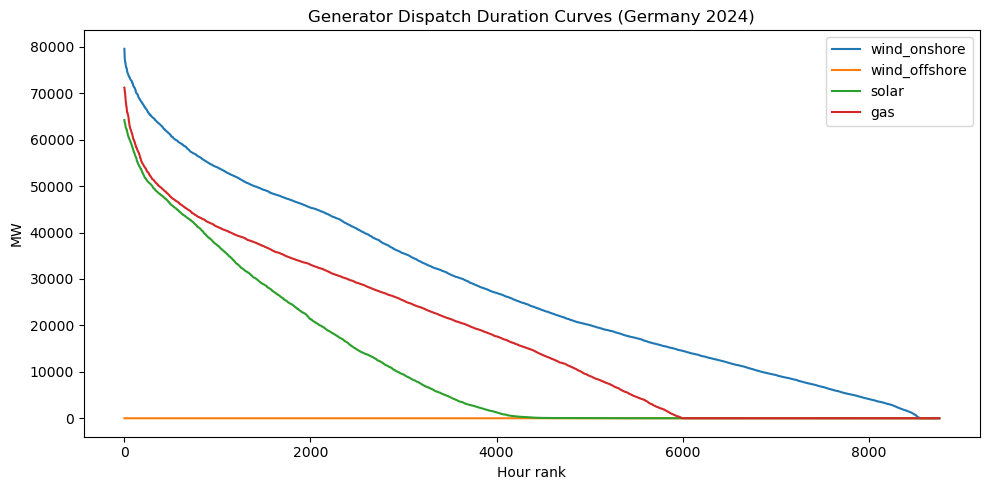


Saved figure in Plots folder.


In [15]:
plt.figure(figsize=(10, 5))
for gen_name in n.generators.index:
    sorted_dispatch = n.generators_t.p[gen_name].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=gen_name)

plt.title("Generator Dispatch Duration Curves (Germany 2024)")
plt.xlabel("Hour rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "duration_curves.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

# Section B
Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.


**Load different generation profiles**

For that we create a function that can extract the generation data from each individual file and we run it through a for loop for every single generation file and we put this data into a dictionary {}

In [16]:
def read_generation_file(filepath):
    # Read csv skipping the 2nd row with units
    gen_raw = pd.read_csv(filepath, skiprows=[1])
    gen_raw.columns = [str(c).strip() for c in gen_raw.columns]

    # Identify columns
    GENERATION_TIME_COL = gen_raw.columns[0]
    WIND_OFFSHORE_COL = "Wind offshore"
    WIND_ONSHORE_COL = "Wind onshore"
    SOLAR_COL = "Solar"

    # Parse time
    gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
    gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
    gen_raw = gen_raw.set_index(GENERATION_TIME_COL)

    # Convert timezone to UTC and remove tz info
    if getattr(gen_raw.index, "tz", None) is not None:
        gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
        gen_raw.index.name = "Date"

    # Build clean dataframe
    gen = pd.DataFrame(index=gen_raw.index)
    gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
    gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
    gen["solar"] = parse_number(gen_raw[SOLAR_COL])

    # Clean and resample
    gen = gen.dropna().copy()
    gen = gen.groupby(gen.index).mean()
    gen = gen.resample("1h").mean()
    gen = gen.interpolate(method="time")
    gen = gen[~((gen.index.month == 2) & (gen.index.day == 29))].copy()  # Remove leap day if present

    #print(gen.shape)

    return gen


production_by_year = {}

files = sorted(DATA_DIR.glob("energy-charts_Total_net_electricity_generation_in_Germany_in_*.csv"))

for file in files:
    if "_load" in file.name:
        # Skipping "load" file
        continue

    year = int(file.stem.split("_")[-1])
    df_year = read_generation_file(file)

    df_year = df_year[(df_year.index >= f"{year}-01-01") & (df_year.index < f"{year+1}-01-01")]

    production_by_year[year] = df_year

print("Loaded production years successfully\n", production_by_year.keys())

Loaded production years successfully
 dict_keys([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])


### Installed technology capacities across years (in MW)

      mean_cf_onshore  mean_cf_offshore  mean_cf_solar
year                                                  
2015         0.196066          0.275650       0.115267
2016         0.166605          0.325458       0.109521
2017         0.196302          0.360107       0.108831
2018         0.193496          0.336271       0.116490
2019         0.212783          0.363292       0.109473
2020         0.214036          0.388288       0.108608
2021         0.183852          0.348365       0.100742
2022         0.191274          0.343734       0.108561
2023         0.216868          0.317154       0.092161
2024         0.197945          0.316254       0.091635
2025         0.175846          0.305798       0.095623


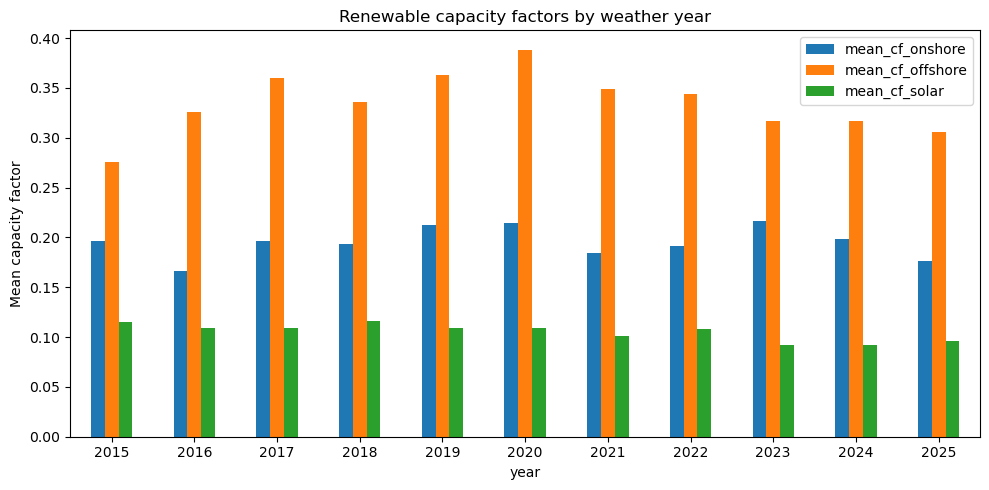

In [30]:
solar_cap = {
2015:36970, 2016:38330, 
2017:39860, 2018:42580, 
2019:46230, 2020:50920, 
2021:56070, 2022:62920, 
2023:76920, 2024:92410, 
2025:107400
}

onshore_cap = {
2015:41300, 2016:45280, 
2017:50170, 2018:52330, 
2019:53190, 2020:54410, 
2021:56050, 2022:58010, 
2023:61010, 2024:63590, 
2025:68220
}

offshore_cap = {
2015:3380, 2016:4240, 
2017:5520, 2018:6510, 
2019:7660, 2020:7870, 
2021:7870, 2022:8220, 
2023:8470, 2024:9220, 
2025:9730
}

cap_factor_each_year = []

for year, df_year in production_by_year.items():

    wind_onshore_cf  = (df_year["wind_onshore"] / onshore_cap[year]).clip(0,1)
    wind_offshore_cf = (df_year["wind_offshore"] / offshore_cap[year]).clip(0,1)
    solar_cf         = (df_year["solar"] / solar_cap[year]).clip(0,1)

    # This is just to calculate mean capacity factor for each technology and plot it
    cap_factor_each_year.append({
        "year": year,
        "mean_cf_onshore": wind_onshore_cf.mean(),
        "mean_cf_offshore": wind_offshore_cf.mean(),
        "mean_cf_solar": solar_cf.mean()
    })

cf_df = pd.DataFrame(cap_factor_each_year).set_index("year").sort_index()

print(cf_df)

cf_df.plot(kind="bar", figsize=(10,5))
plt.ylabel("Mean capacity factor")
plt.title("Renewable capacity factors by weather year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "Cap_factor_per_year.png", dpi=200)
plt.show()
plt.close()

### Network build function per year
**Run model for every single production year**

In [18]:
def run_capacity_expansion_model(wind_onshore_cf, wind_offshore_cf, solar_cf):

    n = pypsa.Network()
    n.set_snapshots(demand_series.index)

    # ___ CARRIERS ___
    n.add("Carrier", "electricity")
    n.add("Carrier", "wind_onshore")
    n.add("Carrier", "wind_offshore")
    n.add("Carrier", "solar")
    n.add("Carrier", "gas")

    # ___ BUSES ___
    n.add("Bus", "electricity", carrier="electricity")

    # ___ LOADS ___
    n.add("Load", "demand", bus="electricity", p_set=demand_series)

    # ___ GENERATORS ___
    n.add(
        "Generator",
        "wind_onshore",
        bus="electricity",
        carrier="wind_onshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshorewind,
        marginal_cost=marginal_cost_onshorewind,
        p_max_pu=wind_onshore_cf
    )

    n.add(
        "Generator",
        "wind_offshore",
        bus="electricity",
        carrier="wind_offshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshorewind,
        marginal_cost=marginal_cost_offshorewind,
        p_max_pu=wind_offshore_cf
    )

    n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=solar_cf
    )

    n.add(
        "Generator",
        "gas",
        bus="electricity",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        p_max_pu=1.0
    )

    n.buses.index = n.buses.index.astype(object)
    n.loads.index = n.loads.index.astype(object)
    n.generators.index = n.generators.index.astype(object)
    n.loads["bus"] = n.loads["bus"].astype(object)
    n.generators["bus"] = n.generators["bus"].astype(object)

    # Solve model
    n.optimize(solver_name="highs")

    # Return optimal capacities
    return n.generators.p_nom_opt

In [19]:
print(demand_series.shape)

(8760,)


#### Optimize per year

In [20]:
part_b_results = []

for year, df_year in production_by_year.items():

    print(f"\nRunning model for weather year {year}")

    # We recompute the cf for every single hour of the year
    wind_onshore_cf  = (df_year["wind_onshore"] / onshore_cap[year]).clip(0,1)
    wind_offshore_cf = (df_year["wind_offshore"] / offshore_cap[year]).clip(0,1)
    solar_cf         = (df_year["solar"] / solar_cap[year]).clip(0,1)

    # IMPORTANT: align timestamps with network snapshots
    wind_onshore_cf.index  = demand_series.index
    wind_offshore_cf.index = demand_series.index
    solar_cf.index         = demand_series.index

    capacities = run_capacity_expansion_model(
        wind_onshore_cf,
        wind_offshore_cf,
        solar_cf
    )

    capacities = capacities.to_dict()
    capacities["year"] = year

    part_b_results.append(capacities)


Running model for weather year 2015


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 171.09it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.65e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Running model for weather year 2016


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 166.33it/s]
INFO:linopy.io: Writing time: 0.19s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.88e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Running model for weather year 2017


...

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 147.01it/s]
INFO:linopy.io: Writing time: 0.25s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.51e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Running model for weather year 2024


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 134.67it/s]
INFO:linopy.io: Writing time: 0.27s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.61e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Running model for weather year 2025


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 176.77it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.78e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


### Plots & Results

In [21]:
part_b_df = pd.DataFrame(part_b_results).set_index("year").sort_index()
mean_capacity = part_b_df.mean()
std_variability = part_b_df.std()
coefficient_of_variation = std_variability / mean_capacity

print("\nOptimal capacities for each weather year:")
print(part_b_df)

summary_b = pd.DataFrame({
    "Mean capacity (MW)": mean_capacity,
    "Std Deviation (MW)": std_variability,
    "Coeff of variation (%)": coefficient_of_variation*100
})

print(summary_b.round(2))


Optimal capacities for each weather year:
       wind_onshore  wind_offshore          solar           gas
year                                                           
2015  160702.189196           -0.0  116306.699958  73802.650558
2016  170768.030006           -0.0  120573.866560  70949.462285
2017  158898.505173           -0.0  113912.041136  74949.106448
2018  170866.533213           -0.0  114236.275445  74374.823144
2019  171793.776554           -0.0  110550.437273  73025.630426
2020  167686.757089           -0.0  111328.164263  71235.007396
2021  170996.044797           -0.0  121898.964953  71539.954429
2022  158231.103956           -0.0  122290.121530  74386.434347
2023  162765.707184           -0.0  120807.030740  70387.981563
2024  172012.565506           -0.0  122564.021221  71202.428511
2025  176116.717597           -0.0  126995.781475  73325.975919
               Mean capacity (MW)  Std Deviation (MW)  Coeff of variation (%)
wind_onshore            167348.90             6

#### Mean and Std deviation capacities

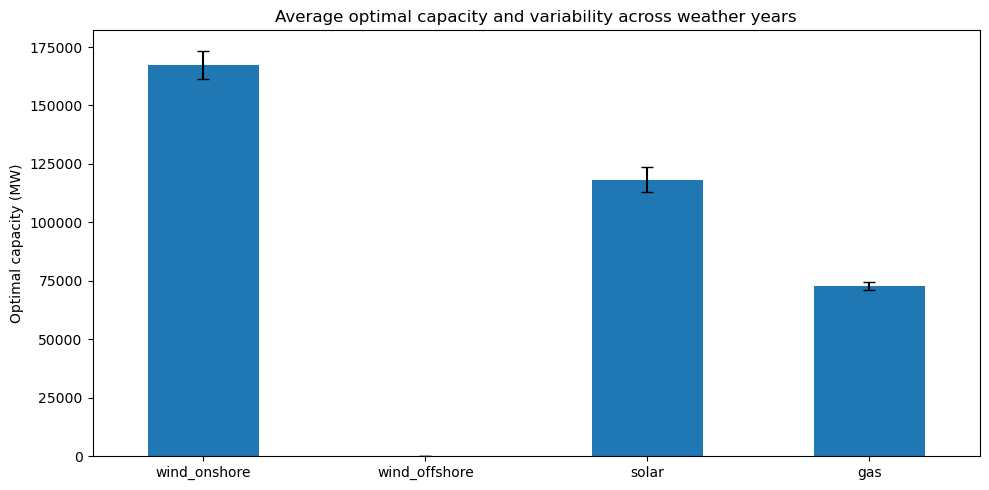


Saved figure in Plots folder.


In [22]:
mean_capacity.plot(kind="bar", yerr=std_variability, capsize=4, figsize=(10,5))
plt.ylabel("Optimal capacity (MW)")
plt.title("Average optimal capacity and variability across weather years")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "capacity_variability.png", dpi=200)
plt.show()
plt.close()
print("\nSaved figure in Plots folder.")   

#### Optimal capacities across years

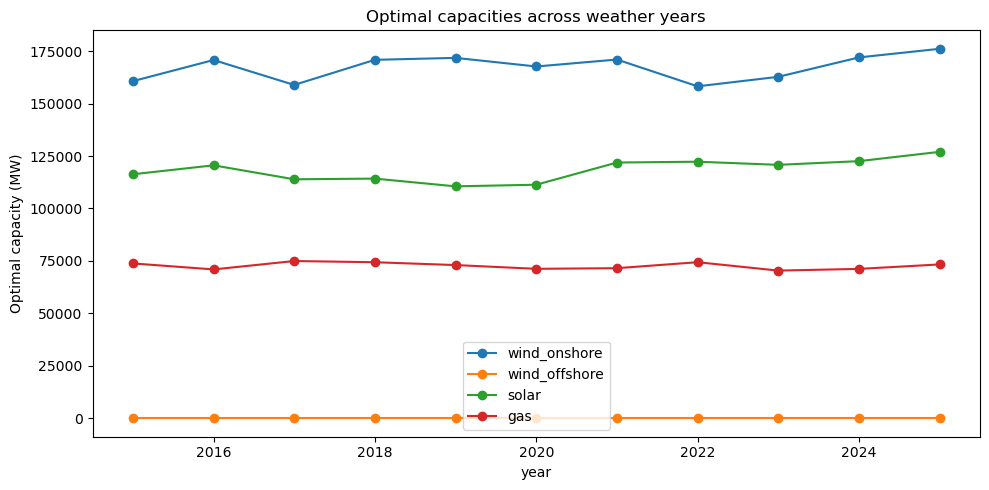


Saved figure in Plots folder.


In [23]:
part_b_df.plot(marker="o", figsize=(10,5))
plt.ylabel("Optimal capacity (MW)")
plt.title("Optimal capacities across weather years")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "Opt_cap_across_years.png", dpi=200)
plt.show()
plt.close()
print("\nSaved figure in Plots folder.")   

# Section C
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


In [24]:
# Starting from your best model in (a)/(b): add storage and re-optimise

# Example (StorageUnit):
# n.add(
#     "StorageUnit",
#     "battery",
#     bus=region,
#     p_nom_extendable=True,
#     max_hours=4,
#     capital_cost=...,  # reference in report
#     marginal_cost=0.0,
#     efficiency_store=0.95,
#     efficiency_dispatch=0.95,
# )
#
# n.optimize(solver_name=SOLVER_NAME)
#
# n.storage_units_t.p.plot(figsize=(10, 3)); plt.title("Storage dispatch")
# n.storage_units_t.state_of_charge.plot(figsize=(10, 3)); plt.title("State of charge")


# Section D
Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.


In [25]:
# Build a multi-area network with at least 4 buses (home + 3 neighbours)
# Ensure at least one cycle in the line topology

# areas = ["<HOME>", "<N1>", "<N2>", "<N3>"]
# n = pypsa.Network()
# n.set_snapshots(snapshots)
# for a in areas:
#     n.add("Bus", a)
#     n.add("Load", f"load_{a}", bus=a, p_set=...)
#     # add generators in each area (fixed or extendable)
#
# interconnectors = {
#     # ("<HOME>", "<N1>"): {"s_nom": ...},
#     # ("<N1>", "<N2>"): {"s_nom": ...},
#     # ("<N2>", "<HOME>"): {"s_nom": ...},  # closes a cycle
#     # ("<HOME>", "<N3>"): {"s_nom": ...},
# }
# for (b0, b1), p in interconnectors.items():
#     n.add(
#         "Line",
#         f"{b0}-{b1}",
#         bus0=b0,
#         bus1=b1,
#         s_nom=p["s_nom"],
#         x=0.1,
#         v_nom=400.0,
#     )
#
# n.optimize(solver_name=SOLVER_NAME)


# Section E
(Note: this section must be solved with pen and paper. The objective is to replicate the power flows that you obtained for the first time step in your simulation.)

Calculate the incidence matrix and the power transfer distribution factor (PTDF) matrix of the network that you defined in the previous section. Read from your PyPSA model the imbalances in the first time step in every node (i.e. generation - demand). Assuming linearised AC power flows, and the previously determined PTDF matrix, calculate the optimal power flowing through every line and check that it coincides with the modelled results.


In [26]:
# Helper outputs for the pen-and-paper PTDF calculation (after you solved part d)

# t0 = n.snapshots[0]
#
# gen_t0 = n.generators_t.p.loc[t0]
# load_t0 = n.loads_t.p.loc[t0]
#
# injections = gen_t0.groupby(n.generators.bus).sum().reindex(n.buses.index).fillna(0.0)
# withdrawals = load_t0.groupby(n.loads.bus).sum().reindex(n.buses.index).fillna(0.0)
# imbalance = injections - withdrawals
#
# lines = n.lines[["bus0", "bus1", "x", "s_nom"]].copy()
# flows_t0 = n.lines_t.p0.loc[t0]  # flow from bus0 -> bus1
#
# imbalance, lines, flows_t0
